In [1]:
from __future__ import annotations

import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_ROOT = Path('/zfsauton/scratch/eshau/imgs')
INSTRUCTION_ROOT = Path('/zfsauton/scratch/mineuih/waymax_rs/new_instructions/')


def _find_scene_image(
    *,
    file_idx: int,
    scenario_idx: int,
    start_timestep: int,
    img_root: Path = IMG_ROOT,
) -> Path:
    scene_dir = img_root / f'tfrecord_{file_idx}' / f'scenario_{scenario_idx}'
    if not scene_dir.exists():
        raise FileNotFoundError(f'Scene directory not found: {scene_dir}')

    prefix = f'tfrecord_{file_idx}_scenario_{scenario_idx}_start_{start_timestep}_end_'
    candidates = sorted(scene_dir.glob(prefix + '*.png'))
    if not candidates:
        expected = scene_dir / f'{prefix}{start_timestep + 50}.png'
        raise FileNotFoundError(
            'Scene image not found. Expected something like: '
            f'{expected}'
        )
    return candidates[0]


def show_scene_with_instructions(
    *,
    file_idx: int,
    scenario_idx: int,
    start_timestep: int,
    num_instructions: int = 5,
    fig_w: int = 12,
    fig_h: int = 7,
) -> None:
    image_path = _find_scene_image(
        file_idx=file_idx,
        scenario_idx=scenario_idx,
        start_timestep=start_timestep,
    )
    file_path = INSTRUCTION_ROOT / f"training_tfexample.tfrecord-{file_idx:05d}-of-01000_t{start_timestep}.jsonl"
    record = None
    if file_path.exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            for i, item in enumerate(f):
                if i == scenario_idx:
                    record = json.loads(item)
                    break

    img = mpimg.imread(image_path)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f'tfrecord={file_idx}, scenario={scenario_idx}, start={start_timestep}',
        fontsize=12,
    )
    plt.show()
    if file_path.exists() and record is not None:
        print("Instruction:", end=" ")
        print(record['instruction'])
        annot = record['annotation']
        print(json.dumps(annot, indent=2))


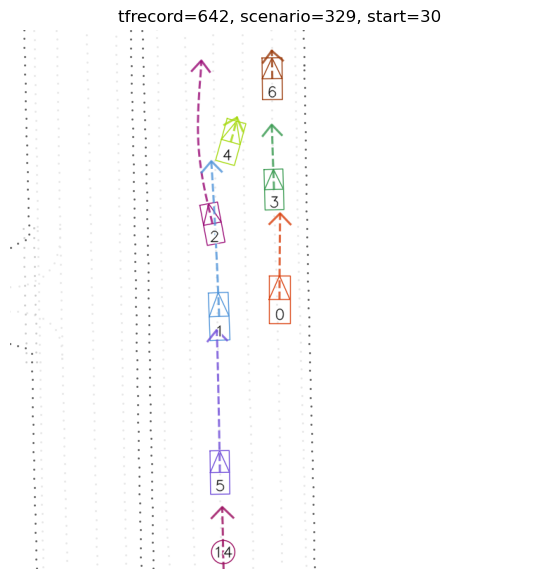

Instruction: go straight while following current lane and slowing down
{
  "scenario_window": {
    "start": 30,
    "end": 80
  },
  "ego_motion": {
    "end_xy": [
      9.472627639770508,
      -0.06499024480581284
    ],
    "end_yaw": -0.007192373275756836,
    "start_speed": 2.7305350303649902,
    "end_speed": 1.2042876482009888,
    "avg_speed": 1.9340450763702393,
    "direction": "straight",
    "turn_label": "straight",
    "lane_change": "none"
  },
  "lane_context": {
    "start_lane_id": 146,
    "end_lane_id": 146,
    "left_lane_ids": [
      151
    ],
    "right_lane_ids": [],
    "traffic_lights": {
      "left": "stop",
      "straight": "stop"
    }
  },
  "vehicles": {
    "front": {
      "object_index": 4,
      "relative_position": [
        12.24504930099519,
        0.6139095994846282
      ],
      "speed": 2.160637617111206,
      "distance": 12.260428923171578
    },
    "rear": null,
    "front_left": {
      "object_index": 6,
      "relative_position": 

In [2]:
import numpy as np
file_idx = np.random.randint(0, 1000)
scenario_idx = np.random.randint(0, 400)
show_scene_with_instructions(
    file_idx=file_idx,
    scenario_idx=scenario_idx,
    start_timestep=30,
)

In [4]:
for file_idx in range(1000):
    file_path = INSTRUCTION_ROOT / f"training_tfexample.tfrecord-{file_idx:05d}-of-01000_t10.jsonl"
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, item in enumerate(f):
            record = json.loads(item)
            if record['annotation']['ego_motion']['turn_label'] == 'u-turn' and 'right' in record['annotation']['ego_motion']['direction']:
                record['annotation']['ego_motion']['turn_label'] = record['annotation']['ego_motion']['direction']
            records.append(record)
    with open(file_path, 'w', encoding='utf-8') as f:
        for record in records:
            f.write(json.dumps(record) + '\n')

In [8]:
u_turn_indices = []
total_count = 0
for file_idx in range(410, 1000):
    file_path = INSTRUCTION_ROOT / f"training_tfexample.tfrecord-{file_idx:05d}-of-01000_t10.jsonl"
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, item in enumerate(f):
            record = json.loads(item)
            if (record['annotation']['ego_motion']['turn_label'] == 'u-turn' and 
                not (record['annotation']['goal']['is_behind'] == 'True')):
                u_turn_indices.append((file_idx, i))
            total_count += 1

print(f"Total u-turns found: {len(u_turn_indices)} out of {total_count} scenarios.")

Total u-turns found: 2332 out of 428415 scenarios.


In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output, display

# Uses existing variables from previous cells if available.
state = {
    'file_idx': u_turn_indices[0][0],
    'scenario_idx': u_turn_indices[0][1],
    'start_timestep': 10,
}
ptr = 0

status = widgets.HTML()
next_btn = widgets.Button(description='Next', button_style='primary')
change_btn = widgets.Button(description='Change', button_style='warning')
more_btn = widgets.Button(description='More Info', button_style='info')
output = widgets.Output()


def _update_turn_label_to_direction(*, file_idx: int, scenario_idx: int, start_timestep: int) -> None:
    file_path = INSTRUCTION_ROOT / f"training_tfexample.tfrecord-{file_idx:05d}-of-01000_t{start_timestep}.jsonl"
    records = []
    updated_record = None

    with file_path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            record = json.loads(line)
            if i == scenario_idx:
                annotation = record.get('annotation', {})
                ego_motion = annotation.get('ego_motion', {})
                direction = ego_motion.get('direction')
                if direction is None:
                    raise KeyError('Missing annotation.ego_motion.direction')
                ego_motion['turn_label'] = direction
                updated_record = record
            records.append(record)

    if updated_record is None:
        raise IndexError(f'Scenario index out of range: {scenario_idx}')

    with file_path.open('w', encoding='utf-8') as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False))
            f.write('\n')


def render_current_scene() -> None:
    status.value = (
        f"<b>file_idx</b>: {state['file_idx']} | "
        f"<b>scenario_idx</b>: {state['scenario_idx']} | "
        f"<b>start_timestep</b>: {state['start_timestep']}"
    )
    with output:
        clear_output(wait=True)
        try:
            show_scene_with_instructions(
                file_idx=state['file_idx'],
                scenario_idx=state['scenario_idx'],
                start_timestep=state['start_timestep'],
                num_instructions=5,
            )
        except Exception as exc:
            print(f'Failed to render scene: {exc}')


def on_next_clicked(_):
    global ptr
    if ptr < len(u_turn_indices) - 1:
        ptr += 1
        state['file_idx'] = u_turn_indices[ptr][0]
        state['scenario_idx'] = u_turn_indices[ptr][1]
        state['start_timestep'] = 10

    # Keep globals in sync so other cells can reuse the latest position.
    globals()['file_idx'] = state['file_idx']
    globals()['scenario_idx'] = state['scenario_idx']
    globals()['start_timestep'] = state['start_timestep']

    render_current_scene()

def on_more_clicked(_):
    state['start_timestep'] = 40
    globals()['start_timestep'] = state['start_timestep']
    globals()['file_idx'] = state['file_idx']
    globals()['scenario_idx'] = state['scenario_idx']
    render_current_scene()
    state['start_timestep'] = 10
    globals()['start_timestep'] = state['start_timestep']
    


def on_change_clicked(_):
    global ptr, u_turn_indices

    try:
        _update_turn_label_to_direction(
            file_idx=state['file_idx'],
            scenario_idx=state['scenario_idx'],
            start_timestep=state['start_timestep'],
        )
    except Exception as exc:
        with output:
            clear_output(wait=True)
            print(f'Failed to update JSONL: {exc}')
        return

    current_key = (state['file_idx'], state['scenario_idx'])
    u_turn_indices = [item for item in u_turn_indices if item != current_key]
    if u_turn_indices:
        ptr = min(ptr, len(u_turn_indices) - 1)
        state['file_idx'], state['scenario_idx'] = u_turn_indices[ptr]
    else:
        ptr = 0

    # Keep globals in sync so other cells can reuse the latest position.
    globals()['file_idx'] = state['file_idx']
    globals()['scenario_idx'] = state['scenario_idx']
    globals()['start_timestep'] = state['start_timestep']

    render_current_scene()


next_btn.on_click(on_next_clicked)
change_btn.on_click(on_change_clicked)
more_btn.on_click(on_more_clicked)

display(widgets.HBox([next_btn, change_btn, more_btn]))
display(status)
display(output)
render_current_scene()

HTML(value='')

Output()

In [7]:

display(widgets.HBox([next_btn, change_btn]))
display(status)
display(output)
render_current_scene()

HTML(value='<b>file_idx</b>: 100 | <b>scenario_idx</b>: 110 | <b>start_timestep</b>: 10')

Output()

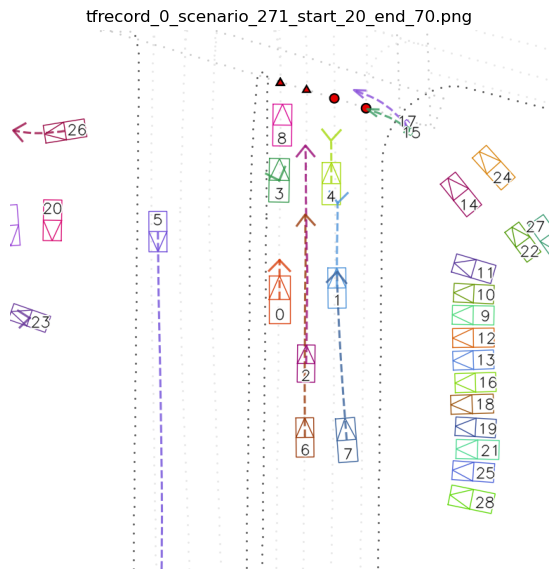

Ego vehicle 0 follows a straight path forward, maintaining its current lane.


In [5]:
import numpy as np
import os
file_path = Path('/zfsauton/scratch/eshau/gemma4_31b_output/gemma4_waymax_structured_full_imgs_s0.jsonl')
with file_path.open('r', encoding='utf-8') as f:
    index = np.random.randint(0, 1000)
    for i, line in enumerate(f):
        if i == index:
            obj = json.loads(line)
            image_path = obj.get('image_path', '(missing)')
            if image_path != '(missing)':
                image_path = "/zfsauton/scratch/eshau/" + image_path
                img = mpimg.imread(image_path)
                plt.figure(figsize=(7, 7))
                plt.imshow(img)
                plt.axis('off')
                plt.title(
                    f'{os.path.basename(image_path)}',
                    fontsize=12,
                )
                plt.show()
                print(obj['parsed']['trajectory_summary'])
            break